In [66]:
%config InlineBackend.figure_format = 'svg'
import warnings
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import random
from scipy.sparse import diags
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
warnings.filterwarnings('ignore')

# Linear Regression

In linear regression, the output variable $y$ is approximated as a linear function of the input variables $x$. The hypothesis $h_{\theta}(x)$ can thus be defined as:

$$
h_{\theta}(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_{d}x_{d} \\
h_{\theta}(x) = \sum_{i=0}^{d}\theta_i x_i
$$

In vector form:
$$
h_{\theta}(x) = \theta^{T}x
$$

where,
$$
\begin{align*}
&\theta = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \vdots \\ \theta_{d} \end{bmatrix}_{d\times 1} \text{are the parameters}\\
&x = \begin{bmatrix} x_0 \\ x_1 \\ \vdots \\ x_{d} \end{bmatrix}_{d\times 1} \text{are the features}\\
&\theta_0 \text{ is the intercept term} \\
&x_0=1 \text{ is the dummy parameter introduced for mathematical convenience}
\end{align*}
$$

## Learning the parameters $(\theta)$

One way to learn/estimate the parameters is to make sure $h_\theta(x)$ is as close to $y$ as possible for the rows in the training set. This can be described mathematically by what is known as a *cost function* $J(\theta)$:

$$
J(\theta) = \frac{1}{2}\sum_{i=1}^{n}\Big(h_{\theta}\big(x^{(i)}\big) - y^{(i)}\Big)^2 
$$

This method of estimating $\theta$ by minimizing the sum of the squared errors/residuals is called the **Ordinary Least Squares Regression Model** and the associated cost function is called the *Least Squares Cost Function*.

### Estimating $\theta$: Normal Equations

Let us define:

\begin{align*}

\mathrm{X} = \begin{bmatrix}
    (x^{(1)})^{T} \\
    (x^{(2)})^{T} \\
    \vdots \\
    (x^{(n)})^{T} \\
\end{bmatrix}_{n\times (d+1)}\quad

\mathrm{Y} = \begin{bmatrix}
    y^{(1)} \\
    y^{(2)} \\
    \vdots \\
    y^{(n)} \\
\end{bmatrix}_{n\times 1} \quad

\theta = \begin{bmatrix}
    \theta_{0} \\
    \theta_{1} \\
    \vdots \\
    \theta_{d} \\
\end{bmatrix}_{(d+1)\times 1}

\end{align*}

Then,
$$
J(\theta) = \frac{1}{2}\sum_{i=1}^{n}\Big(h_{\theta}\big(x^{(i)}\big) - y^{(i)}\Big)^2 = \frac{1}{2}(\mathrm{X}\theta - \mathrm{Y})^T\cdot(\mathrm{X}\theta - \mathrm{Y})
$$

To minimize $J(\theta)$, we set the gradient to 0:

$$
\begin{align*}
\nabla_{\theta} J(\theta) &= 0 \\
\nabla_{\theta} \Big((\mathrm{X}\theta - \mathrm{Y})^T\cdot(\mathrm{X}\theta - \mathrm{Y})\Big) &= 0 \\
(\mathrm{X}\theta - \mathrm{Y})^T \cdot \nabla_{\theta} (\mathrm{X}\theta - \mathrm{Y}) + \nabla_{\theta}(\mathrm{X}\theta - \mathrm{Y})^{T}\cdot(\mathrm{X}\theta - \mathrm{Y}) &= 0 \\
(\mathrm{X}\theta - \mathrm{Y})^T \cdot X + \mathrm{X}^{T}\cdot(\mathrm{X}\theta - \mathrm{Y}) &= 0 \\
(\mathrm{X}\theta)^T \cdot \mathrm{X} - \mathrm{Y}^{T}\mathrm{X} + \mathrm{X}^{T}\cdot(\mathrm{X}\theta) - \mathrm{X}^{T}\mathrm{Y} &= 0 \\
\big(\mathrm{X}^{T}\cdot(\mathrm{X}\theta)\big)^{T} - \big(\mathrm{X}^{T}\mathrm{Y}\big)^{T} + \mathrm{X}^{T}\cdot(\mathrm{X}\theta) - \mathrm{X}^{T}\mathrm{Y} &= 0 \\
2\mathrm{X}^{T}\cdot(\mathrm{X}\theta) - 2\mathrm{X}^{T}\mathrm{Y} &= 0 \\
\mathrm{X}^{T}\cdot(\mathrm{X}\theta) &= \mathrm{X}^{T}\mathrm{Y} \\
\theta &= \mathrm{X}^{-1}(\mathrm{X}^{T})^{-1}\mathrm{X}^{T}\mathrm{Y} \\
\theta &= (\mathrm{X}^{T}\mathrm{X})^{-1}\mathrm{X}^{T}\mathrm{Y} \\
\end{align*}
$$

Therefore, the value of the $\theta$ that minimizes the cost function $J(\theta)$ is given by:
$$
\boxed{\theta = (\mathrm{X}^{T}\mathrm{X})^{-1}\mathrm{X}^{T}\mathrm{Y}} \\
$$

The above set of equations are called the **normal equations**. These equations give us a method to compute the model parameters in one shot. However this comes with a number of downsides:
1. Computing the inverse of a $d\times d$ matrix is $O(d^3)$ time complexity. More the number of features, bigger the time complexity.
2. Storing the inverse itself is expensive: $O(d^2)$ space complexity.
3. $X^{T}X$ may not be an invertible matrix. This can happen if:
    - one or more features are linearly dependent (temperature in fahrenheit and celsius).
    - features are highly correlated, wherein 2 or more features may be related to one other for example (weight and height).
    - the number of features is more than the number of training examples $(d \geq n)$, since we are trying to estimate the solution to a system of linear equations where number of equations is lesser than the number of unknowns.

### Linear Regression Analysis on California Housing Dataset using Normal equations

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


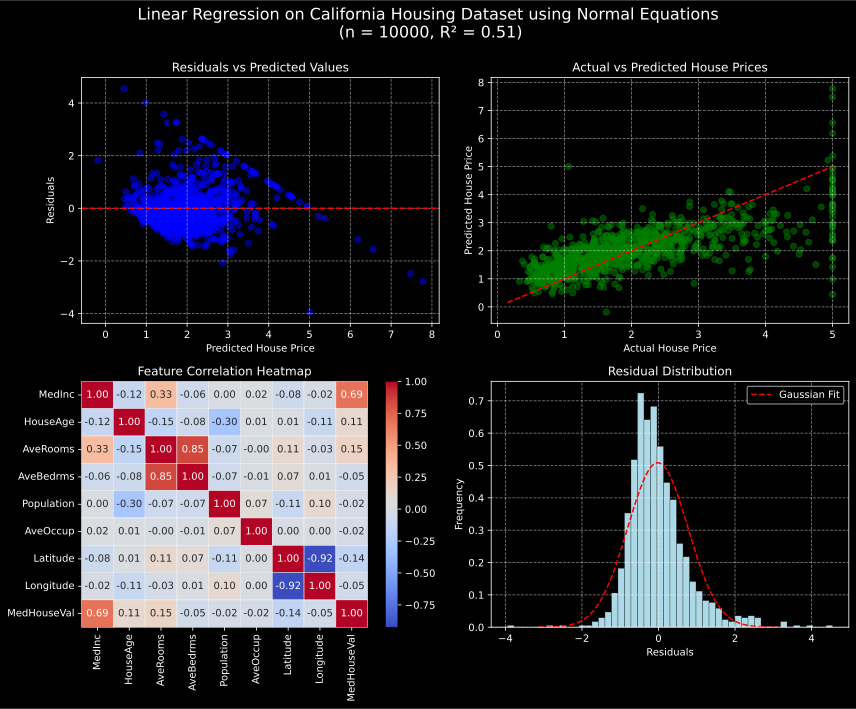

In [67]:
plt.style.use('dark_background')

X = fetch_california_housing().data
Y = fetch_california_housing().target

df = pd.DataFrame(X, columns=fetch_california_housing().feature_names)
df["MedHouseVal"] = Y

print(df.head())

# sample X and Y for training
training_sample_size = 10000
indices = random.sample(range(X.shape[0]), training_sample_size)
X_train = X[indices]
Y_train = Y[indices]

# compute the parameters using the normal equation
Theta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train

# test the model on a set of random samples
test_samples_size = 1000
indices = random.sample(range(X.shape[0]), test_samples_size)
X_test = X[indices]
Y_test = Y[indices]
Y_pred = X_test @ Theta

# errors
residuals = Y_test - Y_pred

# calculate R-squared
ss_total = np.sum((Y_test - np.mean(Y_test)) ** 2)
ss_residual = np.sum((Y_test - Y_pred) ** 2)
r_squared = 1 - (ss_residual / ss_total)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# plot gaussian distribution of residuals
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)
test_input = np.linspace(mean_residual - 4*std_residual, mean_residual + 4*std_residual, 1000) # -4sigma to +4sigma range
pdf = (1 / (std_residual * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((test_input - mean_residual) / std_residual) ** 2)

axes[0, 0].scatter(Y_pred, residuals, alpha=0.5, color='blue')
axes[0, 0].axhline(0, color='red', linestyle='--') # line for zero residuals
axes[0, 0].set_xlabel("Predicted House Price")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Predicted Values")
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

axes[0, 1].scatter(Y_test, Y_pred, alpha=0.5, color='green')
axes[0, 1].plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--') # line for perfect predictions
axes[0, 1].set_xlabel("Actual House Price")
axes[0, 1].set_ylabel("Predicted House Price")
axes[0, 1].set_title("Actual vs Predicted House Prices")
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title("Feature Correlation Heatmap")

axes[1, 1].hist(residuals, bins=50, color='lightblue', linewidth=0.25, edgecolor='black', density=True)
axes[1, 1].set_xlabel("Residuals")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Residual Distribution")
axes[1, 1].grid(True, linestyle='--', alpha=0.5)
axes[1, 1].plot(test_input, pdf, color='red', linestyle='--', label='Gaussian Fit')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.suptitle("Linear Regression on California Housing Dataset using Normal Equations\n (n = {}, R² = {:.2f})".format(training_sample_size, r_squared), fontsize=16)
plt.show()

### Estimating $\theta$: Gradient Descent - An iterative algorithm

Previously, we saw that the normal equations give us a set of $d$ equations which can be used to estimate the model parameters $\theta$ in one-shot. This works great for small datasets, but on larger datasets $(n > 10000)$, computing $\theta$ becomes expensive. In this section, we will come up with an algorithm that iteratively converges to the correct parameters.

Let us look at the cost function again:
$$
J(\theta) = \frac{1}{2}\sum_{i=1}^{n}\Big(h_{\theta}\big(x^{(i)}\big) - y^{(i)}\Big)^2
$$

An alternative way to minimize error is to initialize $\theta$ (often with zeros) and update it iteratively in the direction that most reduces $J(\theta)$. At each step, we evaluate how $J(\theta)$ changes with respect to the parameters and move $\theta$ accordingly; repeated updates gradually improve the estimates and converge to an optimal $\hat{\theta}$. Now, we may ask ourselves – what if there are several local minimas? While gradient descent can be affected by the presence of local minimas, for this specific cost function, notice that $J(\theta) >= 0$ and is a convex quadratic function. Hence, a single minima which is also the global minima is guaranteed. This is described formally below:

$$
\begin{align*}
\theta_{j} &:= \theta_{j} - \alpha\frac{\partial}{\partial \theta_{j}}J(\theta) \\
&= \theta_{j} - \alpha\frac{\partial}{\partial \theta_{j}}\Bigg(\frac{1}{2}\sum_{i=1}^{n}\Big(h_{\theta}\big(x^{(i)}\big) - y^{(i)}\Big)^2\Bigg) \\
&= \theta_{j} - \frac{1}{2}\alpha\sum_{i=1}^{n}\frac{\partial}{\partial \theta_{j}}\Big(\theta^{T}x^{(i)} - y^{(i)}\Big)^2 \\
&= \theta_{j} - \alpha\sum_{i=1}^{n}\Big(\theta^{T}x^{(i)} - y^{(i)}\Big)\cdot\frac{\partial}{\partial \theta_{j}}\Big(\theta^{T}x^{(i)} - y^{(i)}\Big) \\
&= \theta_{j} - \alpha\sum_{i=1}^{n}\Big(h_{\theta}\big(x^{(i)}\big) - y^{(i)}\Big)\cdot x_{j}^{(i)} \\
&= \theta_{j} + \alpha\sum_{i=1}^{n}\Big(y^{(i)} - h_{\theta}\big(x^{(i)}\big)\Big)\cdot x_{j}^{(i)} \\
\end{align*}
$$

$$
\therefore\quad \boxed{\theta_{j} := \theta_{j} + \alpha\sum_{i=1}^{n}\Big(y^{(i)} - h_{\theta}\big(x^{(i)}\big)\Big)\cdot x_{j}^{(i)}}
$$

For a single training example $(n=1)$, we get what is known as the **LMS update rule**:
$$
\quad\boxed{\theta_{j} := \theta_{j} + \alpha \big(y^{(i)} - h_{\theta}\big(x^{(i)}\big)\big)\cdot x_{j}^{(i)}}
$$

Grouping all the $\theta_j$ updates and rewriting in vector form in terms of $\theta$,
$$
\boxed{\theta := \theta + \alpha\sum_{i=1}^{n}\Big(y^{(i)} - h_{\theta}\big(x^{(i)}\big)\Big)\cdot x^{(i)}}
$$

where $\alpha$ is the **learning rate**. It can be thought of the size of the step we take in each direction. If $\alpha$ is too high, the gradient descent path will be chaotic and may not converge. On the other hand, if $\alpha$ is very small, it takes many more iterations to converge. In practice, we start with a small value like $0.01$ and tune it based on needs.

The above equation looks at the entire batch of training data on every iteration to compute the correction and is hence called the **Batch Gradient Descent** algorithm. For this very reason, if $n$ is large, batch gradient descent becomes expensive. An alternative that also works equally well, while making computaions cheap is the **Stochastic Gradient Descent** algorithm. In this algorithm, we look at one training example per iteration to compute the corrections. This algorithm is preferred especially when $n$ is very large.
$$
\boxed{\theta := \theta + \alpha\Big(y^{(i)} - h_{\theta}\big(x^{(i)}\big)\Big)\cdot x^{(i)}}
$$

To visualise this, let us consider the following hypothetical 2-parameter cost function:
$$
\begin{align*}
J(\theta) = 2\theta_0^2 + 3\theta_0\theta_1 + 4\theta_1^2 - 5\theta_0 + 6\theta_1 + 10\\
\frac{\partial J(\theta)}{\partial\theta_{0}} = 4\theta_0 + 3\theta_1 - 5 \\
\frac{\partial J(\theta)}{\partial\theta_{1}} = 3\theta_0 + 8\theta_1 + 6 \\
\implies \theta_0 := \theta_0 - \alpha(4\theta_0 + 3\theta_1 - 5) \\
\implies \theta_1 := \theta_1 - \alpha(3\theta_0 + 8\theta_1 + 6)
\end{align*}
$$

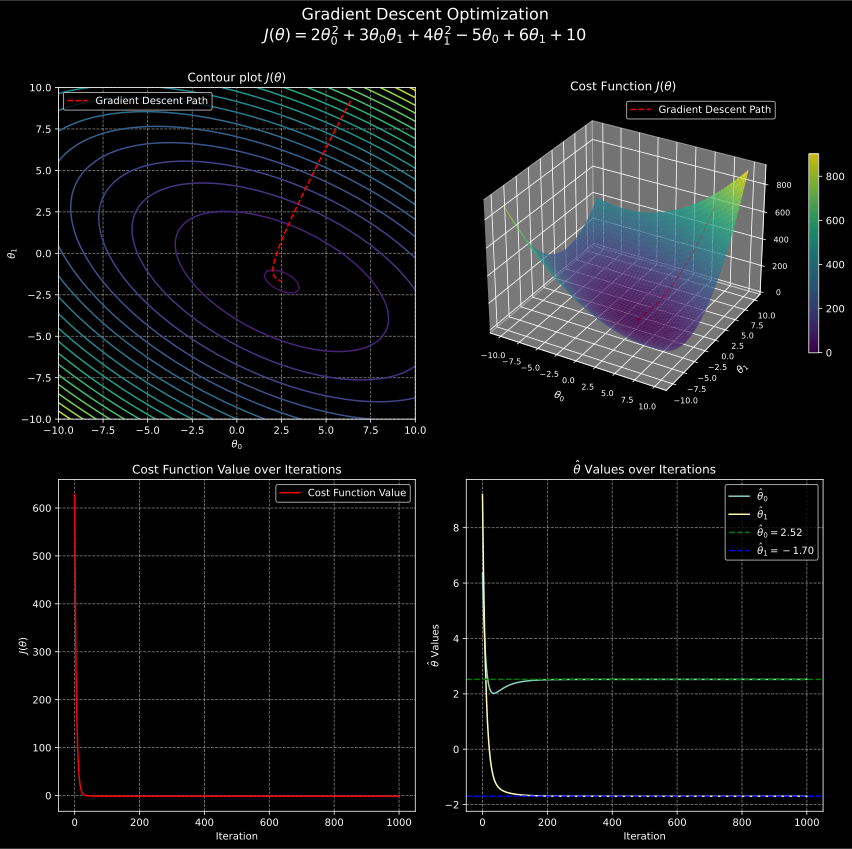

In [ ]:
# generate theta_0, theta_1 for the 3D plot
theta_0 = np.linspace(-10, 10, 100)
theta_1 = np.linspace(-10, 10, 100)

theta_0, theta_1 = np.meshgrid(theta_0, theta_1)

# cost function
cost = 2*theta_0**2 + 3*theta_0*theta_1 + 4*theta_1**2 - 5*theta_0 + 6*theta_1 + 10

# choose a random starting point for gradient descent
est_theta_0 = 70/11
est_theta_1 = 910/99
intial_cost = 2*est_theta_0**2 + 3*est_theta_0*est_theta_1 + 4*est_theta_1**2 - 5*est_theta_0 + 6*est_theta_1 + 10

# gradient descent algorithm
alpha = 0.01
iterations = 1000
points = [(est_theta_0, est_theta_1, intial_cost)]
for i in range(iterations):
    # compute the cost function gradient
    grad_theta_0 = 4*est_theta_0 + 3*est_theta_1 - 5
    grad_theta_1 = 8*est_theta_1 + 3*est_theta_0 + 6
    
    # update theta values
    est_theta_0 -= alpha * grad_theta_0
    est_theta_1 -= alpha * grad_theta_1
    new_cost = 2*est_theta_0**2 + 3*est_theta_0*est_theta_1 + 4*est_theta_1**2 - 5*est_theta_0 + 6*est_theta_1 + 10
    
    points.append((est_theta_0, est_theta_1, new_cost))

fig = plt.figure(figsize=(12, 12))
ax1 = fig.add_subplot(221)
ax1.contour(theta_0, theta_1, cost, levels=20, cmap='viridis')
ax1.set_xlabel('$\\theta_0$')
ax1.set_ylabel('$\\theta_1$')
ax1.set_title('Contour plot $J(\\theta)$')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.plot([p[0] for p in points], [p[1] for p in points], 'r--', label='Gradient Descent Path')
ax1.legend()

ax2 = fig.add_subplot(222, projection='3d')
surf = ax2.plot_surface(theta_0, theta_1, cost, cmap='viridis', alpha=0.8)
ax2.set_xlabel('$\\theta_0$')
ax2.set_ylabel('$\\theta_1$')
ax2.tick_params(axis='x', labelsize=8)
ax2.tick_params(axis='y', labelsize=8)
ax2.tick_params(axis='z', labelsize=8)
ax2.set_title('Cost Function $J(\\theta)$')
fig.colorbar(surf, ax=ax2, fraction=0.04, pad=0.08, shrink=0.6)
ax2.plot([p[0] for p in points], [p[1] for p in points], [p[2] for p in points], color='red', label='Gradient Descent Path', linestyle='--')
ax2.legend()

ax3 = fig.add_subplot(223)
ax3.plot([p[2] for p in points], color='red', label='Cost Function Value')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('$J(\\theta)$')
ax3.set_title('Cost Function Value over Iterations')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend()

ax4 = fig.add_subplot(224)
ax4.plot([p[0] for p in points], label='$\\hat\\theta_0$')
ax4.plot([p[1] for p in points], label='$\\hat\\theta_1$')
ax4.set_xlabel('Iteration')
ax4.set_ylabel('$\\hat\\theta$ Values')
ax4.set_title('$\\hat\\theta$ Values over Iterations')
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.axhline(est_theta_0, color='green', linestyle='--', label=f'$\\hat\\theta_0={est_theta_0:.2f}$')
ax4.axhline(est_theta_1, color='blue', linestyle='--', label=f'$\\hat\\theta_1={est_theta_1:.2f}$')
ax4.legend()

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.suptitle("Gradient Descent Optimization\n$J(\\theta) = 2\\theta_0^2 + 3\\theta_0\\theta_1 + 4\\theta_1^2 - 5\\theta_0 + 6\\theta_1 + 10$", fontsize=16)
plt.show()

## Why is $J(\theta)$ defined so? — Probabilistic justification

We will try to show that the choice of the cost function $J(\theta)$ used so far is a natural consequence of making a few probabilistic assumptions about the nature of the data. Let us start by observing that the target variables $y^{(i)}$, the features $x^{(i)}$ and the parameters $\theta$ are related like so:
$$
y^{(i)} = \theta^{T}x^{(i)} + \epsilon^{(i)}
$$
where $\epsilon^{(i)}$ is the residual/error term. Let us assume that the error terms are normally distributed with mean $0$ and some variance $\sigma^2$:
$$
\epsilon^{(i)} \sim \mathcal{N}(0, \sigma^2) \\
\begin{align*}
\implies P(\epsilon^{(i)}) &= \frac{1}{\sigma\sqrt{2\pi}}\exp\bigg(-\frac{{\epsilon^{(i)}}^{2}}{2\sigma^2}\bigg) \\
\implies P(y^{(i)} \mid x^{(i)}; \theta) &= \frac{1}{\sigma\sqrt{2\pi}}\exp\bigg(-\frac{(y^{(i)} - \theta^{T}x^{(i)})^{2}}{2\sigma^2}\bigg)
\end{align*}
$$

We now introduce a quantity called the **Likelihood function** $L(\theta)$. This is a quantity that describes the following: given a set of features and outputs, how well does $\theta$ describe the model? The quantity is defined so:
$$
L(\theta) = L(\theta \mid X, y) = P(y \mid X; \theta)
$$
where $X$ is the $n \times (d + 1)$ feature matrix and $y$ is the vector of target variables. Assuming that $\epsilon^{(i)}$ are IID (independent and identically distributed), we can claim that the $P(y \mid X; \theta)$ is simply the product of the individual probabilities $P(y^{(i)} \mid x^{(i)}; \theta)$:
$$
\begin{align*}
P(y \mid X; \theta) &= \prod_{i=1}^{n}P(y^{(i)} \mid x^{(i)}; \theta) \\
L(\theta) &= \prod_{i=1}^{n}\frac{1}{\sigma\sqrt{2\pi}}\exp\bigg(-\frac{(y^{(i)} - \theta^{T}x^{(i)})^{2}}{2\sigma^2}\bigg) \\
&= \Bigg(\frac{1}{\sigma\sqrt{2\pi}}\Bigg)^n \exp\bigg(-\sum_{i=1}^{n}\frac{(y^{(i)} - \theta^{T}x^{(i)})^{2}}{2\sigma^2}\bigg) \\
\end{align*}
$$

Defining the **Log Likelihood function** $\ell(\theta) = \ln L(\theta)$:
$$
\begin{align*}
\ell(\theta) &= n\ln\Bigg(\frac{1}{\sigma\sqrt{2\pi}}\Bigg) - \sum_{i=1}^{n}\frac{(y^{(i)} - \theta^{T}x^{(i)})^{2}}{2\sigma^2} \\
&= n\ln\Bigg(\frac{1}{\sigma\sqrt{2\pi}}\Bigg) - \frac{1}{\sigma^2}\cdot\frac{1}{2}\sum_{i=1}^{n}(\theta^{T}x^{(i)} - y^{(i)})^{2}
\end{align*}
$$

Now, to choose the optimal $\theta$, we essentially need to maximise $L(\theta)$, so that the observed inputs and outputs, $P(y \mid X; \theta)$, are highly probable. This is called **Maximum Likelihood Estimation**. Also note, that since $\ln$ is a monotonically increasing function, maximising $L(\theta)$ is equivalent to maximising the log-likelihood $\ell(\theta)$.
$$
\therefore\quad\boxed{\theta^{*} = \argmax_{\theta} L(\theta) = \argmax_{\theta}\ell(\theta) = \argmin_{\theta}\frac{1}{2}\sum_{i=1}^{n}{\epsilon^{(i)}}^{2} = \argmin_{\theta}J(\theta)}\\
$$

Thus, linear regression tries to choose the optimal $\theta$ by performing MLE estimation, which is equivalent to minimizing the cost function that we started with. Revisiting a couple of assumptions we made:
- **$\epsilon^{(i)}$ are distributed as Gaussian**: This is due to the *central limit theorem*. Many small unmodelled effects approximate Gaussian Noise. It is also convenient to explain the squared errors, which follows when a lot of other distributions are also used, but Gaussian is a convenient statistical model to use as it works well as a reasonable approximation in many settings.
- **$\epsilon^{(i)}$ are IID**: This is an assumption made to make the math simpler. *Independent* means that the error from one measurement doesn't affect the other measurement — $\epsilon^{(i)} \perp \epsilon^{(j)}$. *Identical* means the variance in the error of each measurement is the same — $Var(\epsilon^{(i)}) = \sigma^2$. But even if they aren't IID, turns out the estimates produced with this assumption aren't that bad practically.

## Locally Weighted Linear Regression

The linear regression algorithm we have seen so far is an example of a **parametric learning algorithm**, wherin we try to fit a set of parameters to the training data. Notice that, once the training is complete, the model just has to store the parameters in memory and can discard the training data to make predictions.

Locally weighted linear regression is an example of a **non-parametric learning algorithm**, wherein the model has to retain the entire training set in memory to make predictions. The idea behind this algorithm is that in order to make predictions for a set of inputs $x$, we perform linear regression in the neighbourhood of $x$. Mathematically, the cost function to be minimized can be formulated as follows:

$$
J(\theta) = \frac{1}{2}\sum_{i=1}^{n}w^{(i)}\cdot\big(x^{(i)} - \theta^{T}x^{(i)}\big)^2
$$

where $w^{(i)}$ is the set of weights associated with the $i^{th}$ input vector $x^{(i)}$, commonly defined as a Guassian function:
$$
w^{(i)}(x) = w^{(i)} = \exp\bigg(-\frac{(x^{(i)} - x)^{T}(x^{(i)} - x)}{2\tau^2}\bigg)
$$

where $\tau$ is the **bandwidth parameter** and controls how quickly the weights for training example $x^{(i)}$ fall off with distance from $x$. We can use the same methods we have used so far to mimimize the cost function. Notice that the cost function is not much different from the linear regression cost function, except for the addition of the weighting funtion $w(x)$. It is straight forward to verify that the *batch gradient descent algorithm* becomes:
$$
\begin{align*}
\theta_{j}(x) &:= \theta_{j}(x) + \alpha w^{(i)}(x)\cdot\big(y^{(i)} - h_{\theta}\big(x^{(i)}\big)\big)\cdot x_{j}^{(i)} &\quad\text{(LMS update)} \\
\theta(x) &:= \theta(x) + \alpha\sum_{i=1}^{n}w^{(i)}(x)\Big(y^{(i)} - h_{\theta}\big(x^{(i)}\big)\Big)\cdot x^{(i)} &\quad\text{(Batch Gradient Descent)} \\
\theta(x) &:= \theta(x) + \alpha w^{(i)}(x)\Big(y^{(i)} - h_{\theta}\big(x^{(i)}\big)\Big)\cdot x^{(i)}&\quad\text{(Stochastic Gradient Descent)} \\
\theta &= (X^{T}WX)^{-1}X^{T}WY &\quad\text{(Normal Equations)}
\end{align*}
$$

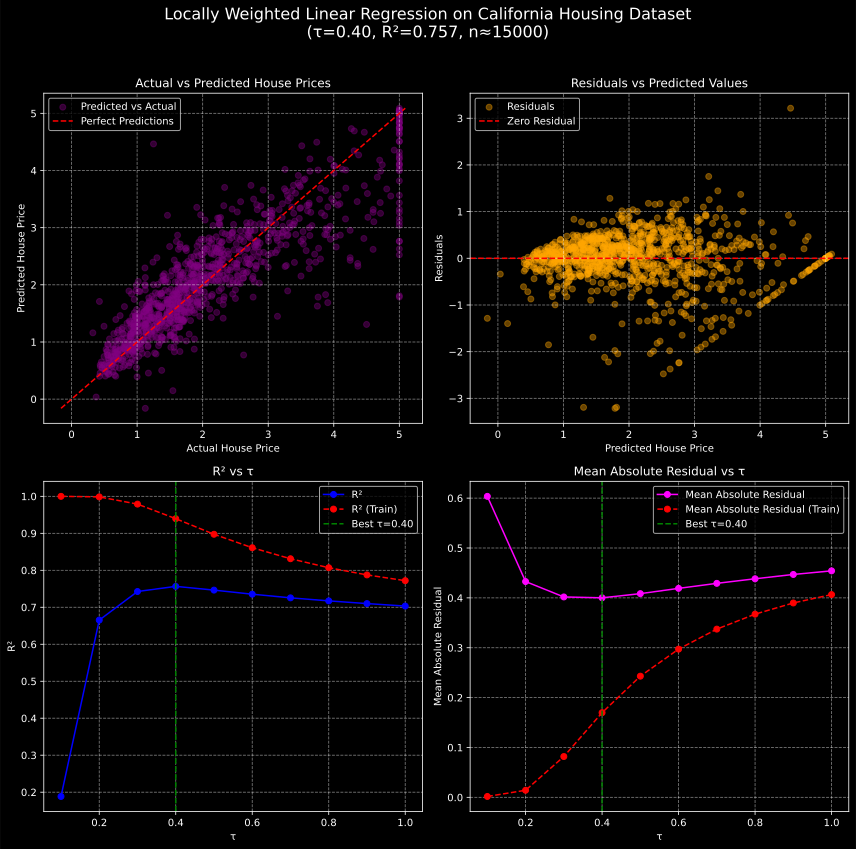

In [69]:
X = fetch_california_housing().data
Y = fetch_california_housing().target
test_size = 0.25
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=42)

# truncate test samples
test_samples_size = 1000
indices = random.sample(range(X_test.shape[0]), test_samples_size)
X_test = X_test[indices]
Y_test = Y_test[indices]

# feature scaling is done to ensure that the weighting function is not dominated by features with larger scales
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# add intercept term (dummy parameter)
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

def lwlr(X_train, Y_train, X_test, tau_range):
    Y_pred = np.zeros((len(X_test), tau_range.shape[0]))

    for i in range(len(X_test)):
        x = X_test[i]
        diff = X_train - x
        dist2 = np.sum(diff**2, axis=1)

        for j, tau in enumerate(tau_range):
            weights = np.exp(-dist2 / (2 * tau**2))
            W = diags(weights)
            theta = np.linalg.pinv(X_train.T @ W @ X_train) @ X_train.T @ W @ Y_train
            Y_pred[i, j] = x @ theta
    
    return Y_pred

# locally weighted linear regression
tau_range = np.linspace(0.1, 1, 10)
Y_pred = lwlr(X_train, Y_train, X_test, tau_range)

# residuals and R² calculation for each τ
residuals = Y_pred - Y_test[:, np.newaxis]
r_squared = np.array([r2_score(Y_test, Y_pred[:, j]) for j in range(Y_pred.shape[1])])
best_tau_index = np.argmax(r_squared)

# evaluate model against training data
train_indices = random.sample(range(X_train.shape[0]), test_samples_size)
X_train = X_train[train_indices]
Y_train = Y_train[train_indices]
Y_train_pred = lwlr(X_train, Y_train, X_train, tau_range)
residuals_train = Y_train_pred - Y_train[:, np.newaxis]
r_squared_train = np.array([r2_score(Y_train, Y_train_pred[:, j]) for j in range(Y_train_pred.shape[1])])

# plots
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].scatter(Y_test, Y_pred[:, best_tau_index], alpha=0.4, color="purple", label="Predicted vs Actual")
lims = [min(Y_test.min(), Y_pred[:, best_tau_index].min()), max(Y_test.max(), Y_pred[:, best_tau_index].max())]
axes[0, 0].plot(lims, lims, "r--", label="Perfect Predictions")
axes[0, 0].set_xlabel("Actual House Price")
axes[0, 0].set_ylabel("Predicted House Price")
axes[0, 0].set_title("Actual vs Predicted House Prices")
axes[0, 0].grid(True, linestyle="--", alpha=0.5)
axes[0, 0].legend()

axes[0, 1].scatter(Y_pred[:, best_tau_index], residuals[:, best_tau_index], alpha=0.4, color="orange", label="Residuals")
axes[0, 1].axhline(0, color="red", linestyle="--", label="Zero Residual")
axes[0, 1].set_xlabel("Predicted House Price")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].set_title("Residuals vs Predicted Values")
axes[0, 1].grid(True, linestyle="--", alpha=0.5)
axes[0, 1].legend()

# plot R² vs τ
axes[1, 0].plot(tau_range, r_squared, marker="o", linestyle="-", color="blue", label="R²")
axes[1, 0].plot(tau_range, r_squared_train, marker="o", linestyle="--", color="red", label="R² (Train)")
axes[1, 0].axvline(tau_range[best_tau_index], color="green", linestyle="--", label=f"Best τ={tau_range[best_tau_index]:.2f}")
axes[1, 0].set_xlabel("τ")
axes[1, 0].set_ylabel("R²")
axes[1, 0].set_title("R² vs τ")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)
axes[1, 0].legend()

# plot tau vs residuals
axes[1, 1].plot(tau_range, np.mean(np.abs(residuals), axis=0), marker="o", linestyle="-", color="magenta", label="Mean Absolute Residual")
axes[1, 1].plot(tau_range, np.mean(np.abs(residuals_train), axis=0), marker="o", linestyle="--", color="red", label="Mean Absolute Residual (Train)")
axes[1, 1].axvline(tau_range[best_tau_index], color="green", linestyle="--", label=f"Best τ={tau_range[best_tau_index]:.2f}")
axes[1, 1].set_xlabel("τ")
axes[1, 1].set_ylabel("Mean Absolute Residual")
axes[1, 1].set_title("Mean Absolute Residual vs τ")
axes[1, 1].grid(True, linestyle="--", alpha=0.5)
axes[1, 1].legend()

plt.suptitle("Locally Weighted Linear Regression on California Housing Dataset\n(τ={:.2f}, R²={:.3f}, n≈{:.0f})".format(tau_range[best_tau_index], r_squared[best_tau_index], np.round(len(X) * (1 - test_size), -3)), fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The above plots show locally weighted linear regression performed on the california housing dataset. We can see that the $R^2$ value has improved significantly, but otherwise the top two plots look similar. The interesting plots are the bottom ones. A few observations:

- For very small $\tau$, we can see that the error in the predictions on trained data is close to 0, and the error increases non-linearly with increase in $\tau$.
- On the other hand, for very small $\tau$, the error in the predictions on untrained data is very high. The error keeps decreasing until a certain $\tau$, beyond which the error starts increasing again. This is expected as increasing the bandwidth makes the model take into account a lot more values in the prediction neighbourhood and vice versa.
- The plots also demonstrate two important effects: **overfitting** and **underfitting**. When $\tau$ is chosen to be very small, the model fits the training data extremely well, but performs poorly on unseen data. This is called **overfitting**. On the other hand, when $\tau$ is chosen to be too large, the model becomes too smooth and fails to fit both the training and unseen data well. This is called **underfitting**.
- $\tau$ is chosen such that it minimizes the errors on both the trained and untrained data. More sophisticated approaches exist to pick an optimal value, which will be discussed later.
- For extremely large values of $\tau$, the error and $R^2$ curves appear to converge to that of linear regression since the neighbourhood becomes larger and weights converge to 1 across all training samples.